In [219]:
import re
import time
import torch
import random
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from torch.utils.data import TensorDataset,DataLoader

In [220]:
device=torch.device("cpu")
print("Using Device:",device)

Using Device: cpu


DATASET


In [221]:
with open("dataset/normalTrafficTraining.txt","r",encoding="utf-8",errors="ignore") as f:
    normal_lines=f.readlines()

with open("dataset/anomalousTrafficTest.txt","r",encoding="utf-8",errors="ignore") as f:
    attack_lines=f.readlines()

print("Normal Requests:",len(normal_lines))
print("Attack Requests:",len(attack_lines))

Normal Requests: 492000
Attack Requests: 355776


In [222]:
def clean_text(text):
    text=text.lower()
    text=re.sub(r"[^a-zA-Z0-9<>=/'._\-?& ]"," ",text)
    text=re.sub(r"\s+"," ",text).strip()
    return text

normal_lines=[clean_text(x) for x in normal_lines]
attack_lines=[clean_text(x) for x in attack_lines]

print(normal_lines[0])
print(attack_lines[0])

get http //localhost 8080/tienda1/index.jsp http/1.1
get http //localhost 8080/tienda1/publico/anadir.jsp?id=2&nombre=jam f3n ib e9rico&precio=85&cantidad= 27 3b drop table usuarios 3b select from datos where nombre like 27 25&b1=a f1adir al carrito http/1.1


In [223]:
normal_subset=normal_lines[:5000]

attack_subset=attack_lines[:5000]

texts=[]
labels=[]

window_size=3

for i in range(len(normal_subset)-window_size):
    combined_request=" ".join(normal_subset[i:i+window_size])
    texts.append(combined_request)
    labels.append(0)

for i in range(len(attack_subset)-window_size):
    combined_request=" ".join(attack_subset[i:i+window_size])
    texts.append(combined_request)
    labels.append(1)

combined=list(zip(texts,labels))

random.shuffle(combined)

texts,labels=zip(*combined)

texts=list(texts)

labels=list(labels)

print("Total Samples:",len(texts))

print("Normal Samples:",labels.count(0))

print("Attack Samples:",labels.count(1))

Total Samples: 9994
Normal Samples: 4997
Attack Samples: 4997


In [224]:
tokenized=[x.split() for x in texts]
print(tokenized[0])

['connection', 'close']


In [225]:
all_words=[]

for seq in tokenized:
    all_words.extend(seq)

word_counts=Counter(all_words)

most_common=word_counts.most_common(3000)

vocab=sorted([w for w,c in most_common])

stoi={s:i+1 for i,s in enumerate(vocab)}
itos={i:s for s,i in stoi.items()}

vocab_size=len(vocab)+1

print("Vocabulary Size:",vocab_size)

Vocabulary Size: 1669


In [226]:
max_len=40

X=[]

for seq in tokenized:
    encoded=[stoi[w] for w in seq if w in stoi]

    if len(encoded)>max_len:
        encoded=encoded[:max_len]

    while len(encoded)<max_len:
        encoded.append(0)

    X.append(encoded)

X=torch.tensor(X,dtype=torch.long)

Y=torch.tensor(labels,dtype=torch.float)

print(X.shape)

print(Y.shape)

torch.Size([9994, 40])
torch.Size([9994])


In [227]:
X_train,X_test,Y_train,Y_test=train_test_split(
    X,
    Y,
    test_size=0.2,
    random_state=42
)

train_dataset=TensorDataset(X_train,Y_train)
test_dataset=TensorDataset(X_test,Y_test)

train_loader=DataLoader(
    train_dataset,
    batch_size=256,
    shuffle=True
)

test_loader=DataLoader(
    test_dataset,
    batch_size=256
)

MLP


In [228]:
class MLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.emb=nn.Embedding(vocab_size,8)

        self.fc1=nn.Linear(max_len*8,16)

        self.dropout=nn.Dropout(0.5)

        self.fc2=nn.Linear(16,1)

    def forward(self,x):
        x=self.emb(x)

        x=x.view(x.shape[0],-1)

        x=torch.relu(self.fc1(x))

        x=self.dropout(x)

        x=self.fc2(x)

        return x.squeeze()

model_mlp=MLP().to(device)

optimizer_mlp=torch.optim.Adam(
    model_mlp.parameters(),
    lr=0.003
)

losses_mlp=[]

In [229]:
start=time.time()

for epoch in range(8):
    total_loss=0

    for xb,yb in train_loader:
        logits=model_mlp(xb)

        loss=F.binary_cross_entropy_with_logits(
            logits,
            yb
        )

        optimizer_mlp.zero_grad()

        loss.backward()

        optimizer_mlp.step()

        total_loss+=loss.item()

    avg_loss=total_loss/len(train_loader)

    losses_mlp.append(avg_loss)

    print(f"MLP Epoch {epoch+1} Loss: {avg_loss}")

end=time.time()

print("MLP Training Time:",round(end-start,2),"seconds")

MLP Epoch 1 Loss: 0.6959628164768219
MLP Epoch 2 Loss: 0.6923018582165241
MLP Epoch 3 Loss: 0.6896595135331154
MLP Epoch 4 Loss: 0.6885524559766054
MLP Epoch 5 Loss: 0.685793574899435
MLP Epoch 6 Loss: 0.6807090081274509
MLP Epoch 7 Loss: 0.6725005712360144
MLP Epoch 8 Loss: 0.6672580949962139
MLP Training Time: 2.05 seconds


MLP+BN

In [230]:
class MLP_BN(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb=nn.Embedding(vocab_size,8)
        self.fc1=nn.Linear(max_len*8,16)
        self.bn=nn.BatchNorm1d(16)
        self.dropout=nn.Dropout(0.5)
        self.fc2=nn.Linear(16,1)

    def forward(self,x):
        x=self.emb(x)

        x=x.view(x.shape[0],-1)

        x=self.fc1(x)

        x=self.bn(x)

        x=torch.relu(x)

        x=self.dropout(x)

        x=self.fc2(x)

        return x.squeeze()

model_bn=MLP_BN().to(device)

optimizer_bn=torch.optim.Adam(
    model_bn.parameters(),
    lr=0.003
)

losses_bn=[]

In [231]:
start=time.time()

for epoch in range(8):
    total_loss=0

    for xb,yb in train_loader:
        logits=model_bn(xb)

        loss=F.binary_cross_entropy_with_logits(
            logits,
            yb
        )

        optimizer_bn.zero_grad()

        loss.backward()

        optimizer_bn.step()

        total_loss+=loss.item()

    avg_loss=total_loss/len(train_loader)

    losses_bn.append(avg_loss)

    print(f"MLP+BN Epoch {epoch+1} Loss: {avg_loss}")

end=time.time()

print("MLP+BN Training Time:",round(end-start,2),"seconds")

MLP+BN Epoch 1 Loss: 0.7005112022161484
MLP+BN Epoch 2 Loss: 0.683513481169939
MLP+BN Epoch 3 Loss: 0.6768537573516369
MLP+BN Epoch 4 Loss: 0.6674352996051311
MLP+BN Epoch 5 Loss: 0.6642438359558582
MLP+BN Epoch 6 Loss: 0.654909947887063
MLP+BN Epoch 7 Loss: 0.6464438028633595
MLP+BN Epoch 8 Loss: 0.6323784291744232
MLP+BN Training Time: 2.27 seconds


LSTM MODEL


In [ ]:
class LSTM_Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.emb = nn.Embedding(vocab_size, 16)
        self.lstm = nn.LSTM(
            input_size=16,
            hidden_size=128,
            batch_first=True
        )
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128, 1)
        
    def forward(self, x):
        x = self.emb(x)
        out, (h, c) = self.lstm(x)
        
        # Grab the output of the last time step
        last_out = out[:, -1, :] 
        
        x = self.dropout(last_out)
        x = self.fc(x)
        return x.squeeze()

model_lstm = LSTM_Model().to(device)

# Lower the learning rate specifically for the LSTM
optimizer_lstm = torch.optim.Adam(
    model_lstm.parameters(),
    lr=0.001 
)

In [233]:
start=time.time()

for epoch in range(15):
    total_loss=0

    for xb,yb in train_loader:
        logits=model_lstm(xb)

        loss=F.binary_cross_entropy_with_logits(
            logits,
            yb
        )

        optimizer_lstm.zero_grad()

        loss.backward()

        optimizer_lstm.step()

        total_loss+=loss.item()

    avg_loss=total_loss/len(train_loader)

    losses_lstm.append(avg_loss)

    print(f"LSTM Epoch {epoch+1} Loss: {avg_loss}")

end=time.time()

print("LSTM Training Time:",round(end-start,2),"seconds")

LSTM Epoch 1 Loss: 0.6942573245614767
LSTM Epoch 2 Loss: 0.6934754066169262
LSTM Epoch 3 Loss: 0.6933017410337925
LSTM Epoch 4 Loss: 0.693714739754796
LSTM Epoch 5 Loss: 0.6936261411756277
LSTM Epoch 6 Loss: 0.6933195237070322
LSTM Epoch 7 Loss: 0.6928788181394339
LSTM Epoch 8 Loss: 0.6948926355689764
LSTM Epoch 9 Loss: 0.6932399421930313
LSTM Epoch 10 Loss: 0.6932418886572123
LSTM Epoch 11 Loss: 0.6931395344436169
LSTM Epoch 12 Loss: 0.6934582572430372
LSTM Epoch 13 Loss: 0.6931257229298353
LSTM Epoch 14 Loss: 0.6930647008121014
LSTM Epoch 15 Loss: 0.6926712468266487
LSTM Training Time: 42.14 seconds


GRU MODEL


In [234]:
class GRU_Model(nn.Module):
    def __init__(self):
        super().__init__()

        self.emb=nn.Embedding(vocab_size,16)

        self.gru=nn.GRU(
            input_size=16,
            hidden_size=128,
            batch_first=True
        )

        self.dropout=nn.Dropout(0.3)

        self.fc=nn.Linear(128,1)

    def forward(self,x):
        x=self.emb(x)

        out,h=self.gru(x)

        x=self.dropout(h[-1])

        x=self.fc(x)

        return x.squeeze()

model_gru=GRU_Model().to(device)

optimizer_gru=torch.optim.Adam(
    model_gru.parameters(),
    lr=0.003
)

losses_gru=[]

In [235]:
start=time.time()

for epoch in range(15):
    total_loss=0

    for xb,yb in train_loader:
        logits=model_gru(xb)

        loss=F.binary_cross_entropy_with_logits(
            logits,
            yb
        )

        optimizer_gru.zero_grad()

        loss.backward()

        optimizer_gru.step()

        total_loss+=loss.item()

    avg_loss=total_loss/len(train_loader)

    losses_gru.append(avg_loss)

    print(f"GRU Epoch {epoch+1} Loss: {avg_loss}")

end=time.time()

print("GRU Training Time:",round(end-start,2),"seconds")

GRU Epoch 1 Loss: 0.6951872035861015
GRU Epoch 2 Loss: 0.6946629080921412
GRU Epoch 3 Loss: 0.6933249663561583
GRU Epoch 4 Loss: 0.6908790301531553
GRU Epoch 5 Loss: 0.6643997393548489
GRU Epoch 6 Loss: 0.6092594135552645
GRU Epoch 7 Loss: 0.5502770775929093
GRU Epoch 8 Loss: 0.5129111828282475
GRU Epoch 9 Loss: 0.48572758585214615
GRU Epoch 10 Loss: 0.46768475975841284
GRU Epoch 11 Loss: 0.453364921733737
GRU Epoch 12 Loss: 0.4365660473704338
GRU Epoch 13 Loss: 0.4335437109693885
GRU Epoch 14 Loss: 0.42427145782858133
GRU Epoch 15 Loss: 0.41832985635846853
GRU Training Time: 57.93 seconds


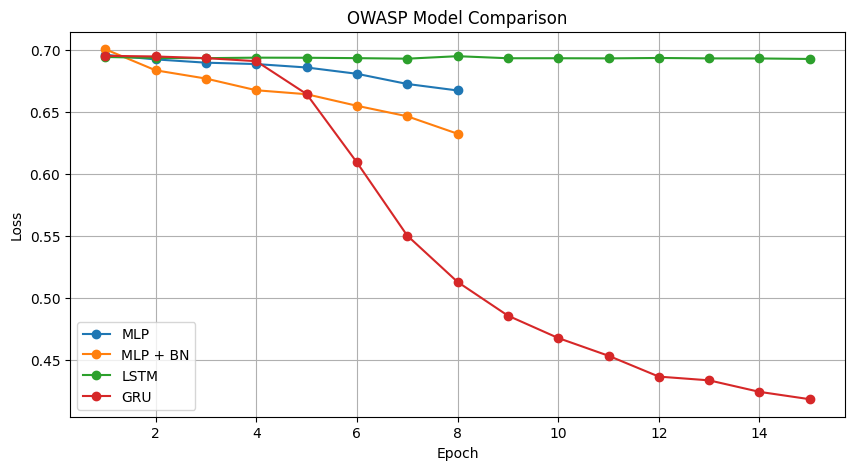

In [236]:
plt.figure(figsize=(10,5))

epochs_mlp=range(1,len(losses_mlp)+1)
epochs_bn=range(1,len(losses_bn)+1)
epochs_lstm=range(1,len(losses_lstm)+1)
epochs_gru=range(1,len(losses_gru)+1)

plt.plot(epochs_mlp,losses_mlp,label="MLP",marker='o')

plt.plot(epochs_bn,losses_bn,label="MLP + BN",marker='o')

plt.plot(epochs_lstm,losses_lstm,label="LSTM",marker='o')

plt.plot(epochs_gru,losses_gru,label="GRU",marker='o')

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("OWASP Model Comparison")

plt.legend()

plt.grid(True)

plt.show()

In [237]:
def evaluate(model,name):
    model.eval()

    all_preds=[]
    all_labels=[]

    with torch.no_grad():
        for xb,yb in test_loader:
            logits=model(xb)

            probs=torch.sigmoid(logits)

            preds=(probs>0.5).float()

            all_preds.extend(preds.numpy())

            all_labels.extend(yb.numpy())

    acc=accuracy_score(all_labels,all_preds)

    print("\n====================")
    print(name)
    print("====================")
    print("Accuracy:",acc)

In [238]:
evaluate(model_mlp,"MLP")
evaluate(model_bn,"MLP + BatchNorm")
evaluate(model_lstm,"LSTM")
evaluate(model_gru,"GRU")


MLP
Accuracy: 0.567783891945973

MLP + BatchNorm
Accuracy: 0.5947973986993497

LSTM
Accuracy: 0.49824912456228115

GRU
Accuracy: 0.7038519259629815


In [243]:
def predict_attack(text,model):
    model.eval()

    text=clean_text(text)

    tokens=text.split()

    encoded=[stoi.get(w,0) for w in tokens]

    if len(encoded)>max_len:
        encoded=encoded[:max_len]

    while len(encoded)<max_len:
        encoded.append(0)

    x=torch.tensor([encoded],dtype=torch.long)

    with torch.no_grad():
        logits=model(x)

        prob=torch.sigmoid(logits).item()

    print("\nRequest:\n")
    print(text)

    print("\nAttack Probability:",prob)

    if prob>0.5:
        print("\n⚠ MALICIOUS OWASP ATTACK DETECTED")
    else:
        print("\n✅ NORMAL REQUEST")

In [ ]:
# Change model_lstm to model_gru for all your tests
normal_test = "GET /products.php?id=10 HTTP/1.1"
predict_attack(normal_test, model_gru)

sql_test = "GET /login.php?id=' OR 1=1 --"
predict_attack(sql_test, model_gru)

xss_test = "GET /search.php?q=<script>alert(1)</script>"
predict_attack(xss_test, model_gru)

path_test = "GET ../../etc/passwd"
predict_attack(path_test, model_gru)


Request:

get /products.php?id=10 http/1.1

Attack Probability: 0.4933049976825714

✅ NORMAL REQUEST

Request:

get /login.php?id=' or 1=1 --

Attack Probability: 0.4933049976825714

✅ NORMAL REQUEST

Request:

get /search.php?q=<script>alert 1 </script>

Attack Probability: 0.4933049976825714

✅ NORMAL REQUEST

Request:

get ../../etc/passwd

Attack Probability: 0.4933049976825714

✅ NORMAL REQUEST


In [196]:
while True:
    user_input=input("\nEnter Request (type quit to stop): ")

    if user_input.lower()=="quit":
        break

    predict_attack(user_input,model_lstm)


Request:

get /login.php?id=' or 1=1 -- http/1.1

Attack Probability: 0.4993268847465515

✅ NORMAL REQUEST
